In [1]:
import numpy as np
import random
from multiprocessing import Pool
import pandas as pd
from scipy.interpolate import interp1d
from scipy.special import gamma
import scipy.stats as stats
from scipy.stats import binom

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
font_manager.fontManager.addfont('/home/vvelan/DarkLim/examples/styles/Times_New_Roman.ttf')

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.style.use('/home/vvelan/DarkLim/examples/styles/Style.mplstyle')

import sys
import darklim
sys.path.insert(0, '/home/vvelan/DarkELF/')
import darkelf

import qetpy
import detprocess
import h5py
import time
import pickle
from time import localtime, strftime
import glob

# Helper Functions

In [2]:
lee_scale = 1 / 400.

def run57_lee_bkgd():
    fin = 'Run57_LEE_templates/combined_spectra_shared57_CRESST_extrap.txt'
    template = np.loadtxt(fin,skiprows=1)
    interp_func = interp1d(template[:,0],template[:,1],
                            bounds_error=False,
                            #fill_value='extrapolate',
                            fill_value=0.,
                            assume_sorted=True)

    return lambda x: (interp_func(x) / 86400.) * lee_scale



def get_closest_time(trigger_times, t):
    """
    Find the closest time in trigger_times to t and its index.
    """
    # Find the index in trigger_times closest to t (trigger_times is sorted)
    idx = np.searchsorted(trigger_times, t)
    if idx == 0:
        closest_idx = 0
    elif idx == len(trigger_times):
        closest_idx = len(trigger_times) - 1
    else:
        if abs(trigger_times[idx] - t) < abs(trigger_times[idx - 1] - t):
            closest_idx = idx
        else:
            closest_idx = idx - 1

    try:
        _ = trigger_times[closest_idx]
    except IndexError:
        print(f"IndexError: closest_idx = {closest_idx}, len(trigger_times) = {len(trigger_times)}")
        sys.exit(1)
    
    # Return the closest time and its index
    return trigger_times[closest_idx], closest_idx



# Load Templates and set up Simulation

In [4]:
### Set the number of desired channels, single-pixel energy resolution, and OF trigger strength in your simulation
n_channels = 4
energy_resolution = 0.0074
n_sigma = 7.0

In [5]:
### Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')

# Load shared 2x1 template to get the energy scale right, but we only use the left-channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
_, _, f_frequencies = templates_td.shape
fs = metadata['sample_rate']
pretrig = metadata['nb_pretrigger_samples']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))



### Convert OF to multichannel format

# Rescale template so that the energy resolution per channel is some assumed value
base_energy_resolution = 0.3977 # eV; this is the resolution of the template loaded above

template_OF = np.zeros((n_channels, n_channels, f_frequencies))
csd_OF = np.zeros((n_channels, n_channels, f_frequencies))
for i in range(n_channels):
    template_OF[i, i, :] = np.copy(templates_td)
    csd_OF[i, i, :] = np.copy(csd) * (energy_resolution / base_energy_resolution)**2



### Simulation parameters

# Single-pixel event rate in Hz for the simulation
# Note: this should be as high as possible without inducing pileup to make the simulation run faster
# Note: if the integrated LEE rate is higher than this, we will use the integrated LEE rate
rate_Hz = 100

# Minimum energy to simulate a pulse (keV)
E_cutoff = 0.18e-3

# Calculate the true LEE rate integrated above E_cutoff
E_arr = np.geomspace(E_cutoff, 100e-3, 250)
dRdE_arr = run57_lee_bkgd()(E_arr)
R_LEE = np.trapz(dRdE_arr, E_arr)
if R_LEE > rate_Hz:
    rate_Hz = R_LEE

print(f'LEE background: {R_LEE:.2e} Hz per pixel above {E_cutoff*1e3:.2f} eV')
print(f'Simulated event rate: {rate_Hz:.2e} Hz per pixel above {E_cutoff*1e3:.2f} eV')

# Amount of time to simulate
# Note: this time is referenced to rate_Hz, not to rate_LEE
full_data_length_hours = 0.01

 # Chunk size
sim_trace_length_s = 10
sim_trace_length = 10 * fs

# Split up the simulation into chunks, which are then split between cores
n_cores = 1
n_simulations = int(np.floor(full_data_length_hours * 3600 / sim_trace_length_s))
n_traces_per_sim = int(sim_trace_length / f_frequencies)
print(f'Running {n_simulations} simulations in parallel with {n_cores} cores')


INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5
LEE background: 2.30e+01 Hz per pixel above 0.18 eV
Simulated event rate: 1.00e+02 Hz per pixel above 0.18 eV
Running 3 simulations in parallel with 1 cores


# Run Simulation

In [ ]:
# Results will be saved in a pickle file 'my_simulation_3fold_{run_id}_{seed_1}_{seed_2}.pkl'
seed_1 = 567
seed_2 = 654
run_id = 0
 
def simulate_and_collect(sim_number):
    """
    Simulate a single run of the experiment (typically 10 seconds) and collect the results.
    """

    rng = np.random.default_rng(seed_1 + sim_number * 100)

    # Simulate pulses in the two pixels
    expected_events = int(rate_Hz * sim_trace_length_s * 2)  # Overestimate to be safe

    # SensEst object to generate the LEE background
    SE = darklim.sensitivity.SensEst(1, 1/86400 * expected_events / R_LEE, tm='GaAs', eff=1., gain=1., seed=seed_2 + sim_number * 100)
    SE.reset_sim()
    SE.add_run57_lee_bkgd(fin='Run57_LEE_templates/combined_spectra_shared57.txt')

    # Simulate noise in the N pixels
    simulated_waveform_joint = qetpy.gen_noise(csd_OF, fs, n_traces_per_sim, rng=rng)
    
    # Reshape so that each pixel is a separate channel
    simulated_waveform_td = np.zeros((n_channels, f_frequencies * n_traces_per_sim))
    for i in range(n_channels):
        for j in range(n_traces_per_sim):
            simulated_waveform_td[i, j * f_frequencies:(j + 1) * f_frequencies] = simulated_waveform_joint[j, i, :]
    
    # Simulate arrival times and energies in each pixel
    for i in range(n_channels):
        arrival_times = np.cumsum(rng.exponential(1.0 / rate_Hz, expected_events)) * fs
        arrival_times = arrival_times[arrival_times < (sim_trace_length - f_frequencies)].astype(int)
        energies_eV = SE.generate_background(100e-3, e_low=E_cutoff) * 1000
    
        # Add pulses to waveform
        for t, atime in enumerate(arrival_times):
            try:
                simulated_waveform_td[i, atime : atime + f_frequencies] += energies_eV[t] * template_OF[i,i]
            except IndexError:
                print(f"IndexError: arrival_times = {len(arrival_times)}, atime = {atime}, t = {t}, expected_events = {expected_events}, simulated_waveform_td.shape = {simulated_waveform_td.shape}")
                sys.exit(1)

    # Process the data with an NxN trigger
    chan_name = '|'.join(f'MyTrigger{i}' for i in range(n_channels))
    oftrigger = detprocess.OptimumFilterTrigger(chan_name, fs, template_OF, csd_OF, pretrigger_samples=pretrig)
    oftrigger.update_trace(simulated_waveform_td)
    dynamic_threshold_function = lambda amp: max(100, 2 * 78 * np.log(amp / 13))
    oftrigger.find_triggers(n_sigma, dynamic=True, dynamic_threshold_function=dynamic_threshold_function)

    # Extract trigger amplitudes and times from the NxN trigger
    trigger_times = oftrigger.get_trigger_data()[chan_name]['trigger_index']
    trigger_delta_chi2 = oftrigger.get_trigger_data()[chan_name]['trigger_delta_chi2']
    n_triggers = len(trigger_times)

    E_matrix = np.zeros((n_channels, n_triggers))
    for i in range(n_channels):
        E_matrix[i, :] = oftrigger.get_trigger_data()[chan_name][f'trigger_amplitude_{i}']

    # For each trigger, compare chi2 values from the three triggers:
    if sim_number % n_cores == 0:
        print(f'In simulation {sim_number}, starting the loop over {n_triggers} times. Currently', strftime("%m-%d %H:%M:%S", localtime()))

    # Reprocess the data with a 1x1 trigger on each pixel
    oftriggers = []
    trigger_times_list = []
    trigger_delta_chi2_list = []

    for i in range(n_channels):
        trig_name = f'MyTrigger{i}'
        oftrig = detprocess.OptimumFilterTrigger(
            trig_name,
            fs,
            template_OF[i, i],
            csd_OF[i, i],
            pretrigger_samples=pretrig
        )
        oftrig.update_trace(simulated_waveform_td[i])
        oftrig.find_triggers(n_sigma, dynamic=True, dynamic_threshold_function=dynamic_threshold_function)
        trigger_times_list.append(oftrig.get_trigger_data()[trig_name]['trigger_index'])
        trigger_delta_chi2_list.append(oftrig.get_trigger_data()[trig_name]['trigger_delta_chi2'])
        oftriggers.append(oftrig)

    # Calculate the chi2 difference between the NxN and sum of 1x1 triggers
    delta_delta = np.zeros(n_triggers)
    associated_trigger_times = np.zeros((n_channels, n_triggers), dtype=int)

    # Loop over the NxN triggers and find the closest 1x1 trigger times
    for t, trigger_time in enumerate(trigger_times):
        delta_chi2_NxN = trigger_delta_chi2[t]
        dchi2_1x1_sum = 0
        for i in range(n_channels):
            times_ch = trigger_times_list[i]
            dchi2s_ch = trigger_delta_chi2_list[i]
            if len(times_ch) == 0:
                dchi2 = 0
            else:
                this_t, idx = get_closest_time(times_ch, trigger_time)
                dchi2 = dchi2s_ch[idx]
                associated_trigger_times[i, t] = this_t
            dchi2_1x1_sum += dchi2
        delta_delta[t] = dchi2_1x1_sum - delta_chi2_NxN

    # Delete the waveform object to free up memory
    del simulated_waveform_td
    
    return E_matrix, trigger_times, delta_delta, associated_trigger_times, [sim_number] * n_triggers


In [ ]:
##################################################################
# Run the simulation in parallel
##################################################################

results = []
for batch_start in range(0, n_simulations, n_cores):
    batch_indices = list(range(batch_start, min(batch_start + n_cores, n_simulations)))
    with Pool(n_cores) as pool:
        batch_results = pool.map(simulate_and_collect, batch_indices)
    results.extend(batch_results)

with open(f'test_simulation_3fold_{run_id}_{seed_1}_{seed_2}.pkl', 'wb') as f:
    pickle.dump(results, f)


In simulation 0, starting the loop over 414 times. Currently 05-27 02:19:04
In simulation 1, starting the loop over 391 times. Currently 05-27 02:19:17
In simulation 2, starting the loop over 384 times. Currently 05-27 02:19:29


In [ ]:
##################################################################
# Load the results from the pickle file
##################################################################

# E_matrix_full[0] will contain energies in pixel 0, etc.
E_matrix_full = [[] for _ in range(n_channels)]

trigger_time_full = []
delta_delta_full = []
sim_number_full = []

for run_id in range(1):
    fns = glob.glob(f'test_simulation_3fold_{run_id}*.pkl')
    with open(fns[0], 'rb') as f:
        results = pickle.load(f)
        
        for i in range(n_channels):
            E_matrix_full[i] += [e for result in results for e in result[0][i]]
            
        trigger_time_full += [e for result in results for e in result[1]]
        delta_delta_full += [e for result in results for e in result[2]]
        sim_number_full += [e for result in results for e in result[3]]
        
        #del results

E_matrix_full = np.array(E_matrix_full)
sim_number_full = np.array(sim_number_full)
trigger_time_full = np.array(trigger_time_full)
delta_delta_full = np.array(delta_delta_full)


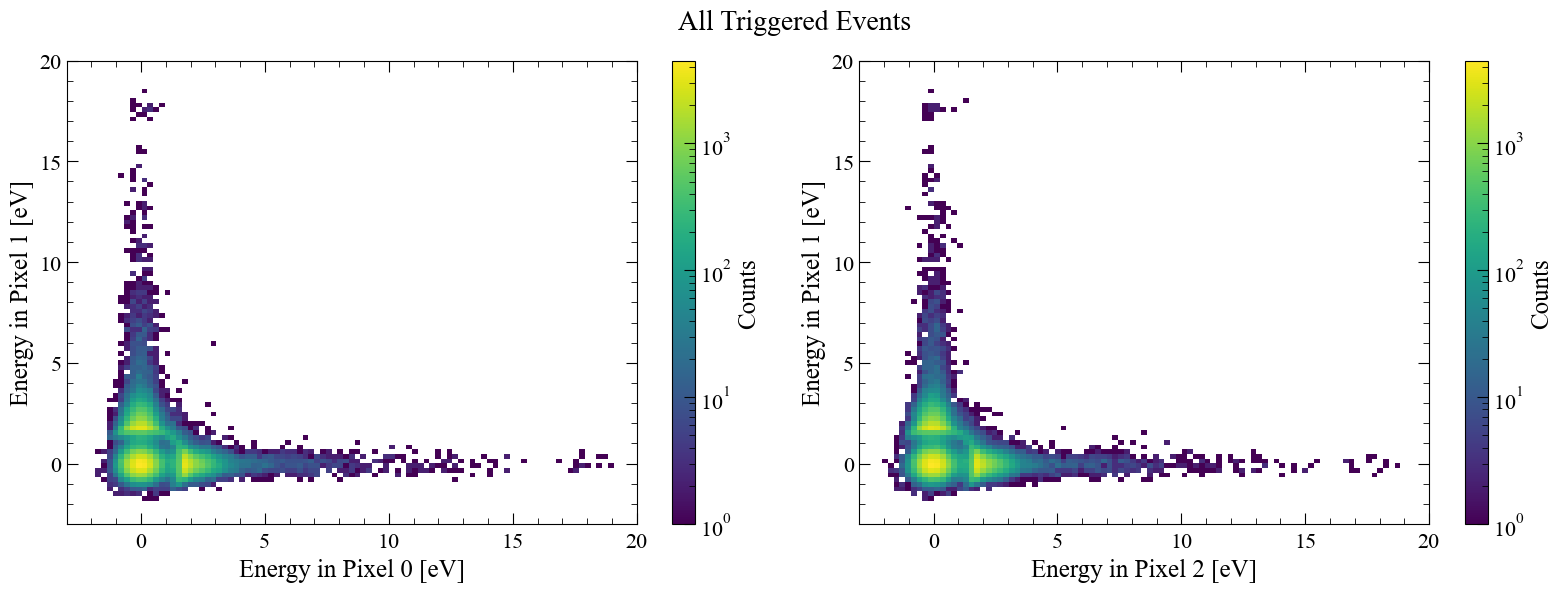

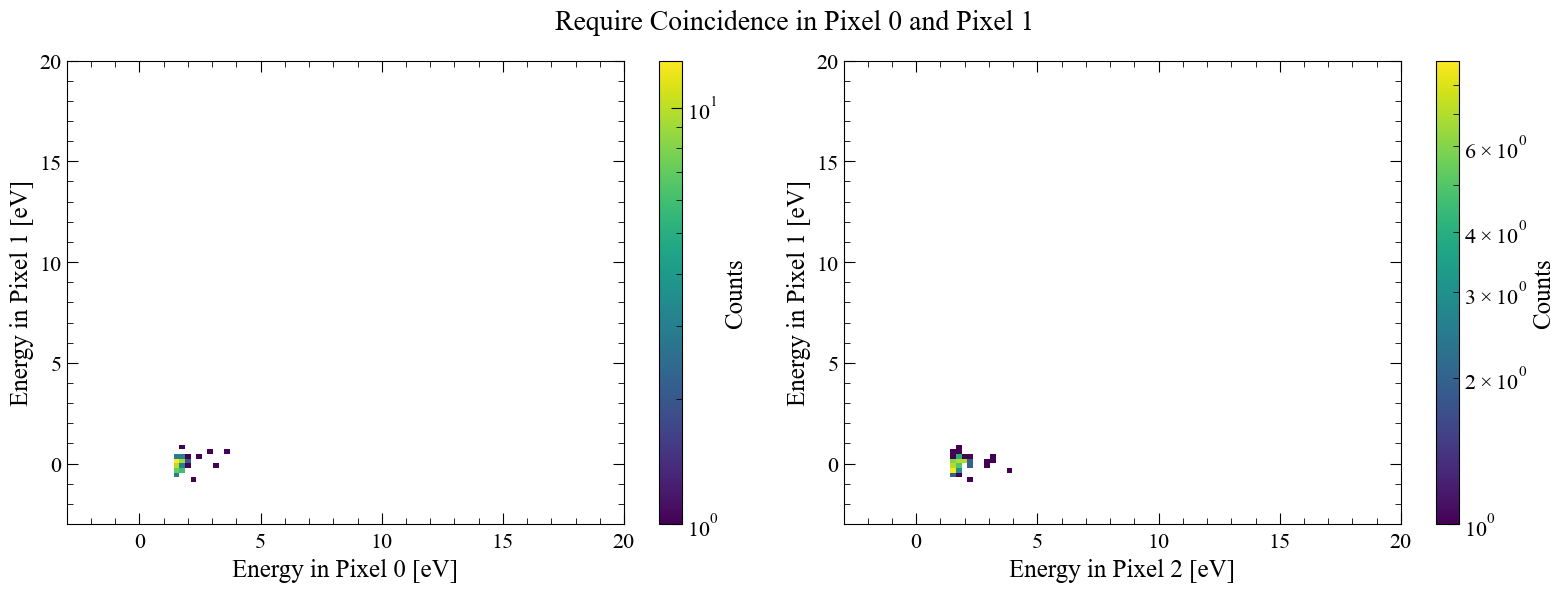

In [ ]:
bins = (np.linspace(-3, 20, 100), np.linspace(-3, 20, 100))

########################################################

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

h = ax[0].hist2d(E_matrix_full[0], E_matrix_full[1],
           bins=bins, norm=mpl.colors.LogNorm(), cmap='viridis', cmin=1)
fig.colorbar(h[3], ax=ax[0], label='Counts')

ax[0].set_xlabel('Energy in Pixel 0 [eV]')
ax[0].set_ylabel('Energy in Pixel 1 [eV]')
ax[0].set_xlim([-3, 20])
ax[0].set_ylim([-3, 20])

h = ax[1].hist2d(E_matrix_full[2], E_matrix_full[1],
           bins=bins, norm=mpl.colors.LogNorm(), cmap='viridis', cmin=1)
fig.colorbar(h[3], ax=ax[1], label='Counts')

ax[1].set_xlabel('Energy in Pixel 2 [eV]')
ax[1].set_ylabel('Energy in Pixel 1 [eV]')
ax[1].set_xlim([-3, 20])
ax[1].set_ylim([-3, 20])

fig.suptitle('All Triggered Events', fontsize=20)
fig.tight_layout()
fig.show()

########################################################

cut_2fold = (E_matrix_full[0] > (n_sigma * energy_resolution)) * (E_matrix_full[2] > (n_sigma * energy_resolution))
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

h = ax[0].hist2d(E_matrix_full[0][cut_2fold], E_matrix_full[1][cut_2fold],
           bins=bins, norm=mpl.colors.LogNorm(), cmap='viridis', cmin=1)
fig.colorbar(h[3], ax=ax[0], label='Counts')

ax[0].set_xlabel('Energy in Pixel 0 [eV]')
ax[0].set_ylabel('Energy in Pixel 1 [eV]')
ax[0].set_xlim([-3, 20])
ax[0].set_ylim([-3, 20])

h = ax[1].hist2d(E_matrix_full[2][cut_2fold], E_matrix_full[1][cut_2fold],
           bins=bins, norm=mpl.colors.LogNorm(), cmap='viridis', cmin=1)
fig.colorbar(h[3], ax=ax[1], label='Counts')

ax[1].set_xlabel('Energy in Pixel 2 [eV]')
ax[1].set_ylabel('Energy in Pixel 1 [eV]')
ax[1].set_xlim([-3, 20])
ax[1].set_ylim([-3, 20])

fig.suptitle('Require Coincidence in Pixel 0 and Pixel 1', fontsize=20)
fig.tight_layout()
fig.show()



# Simulate only Noise

In [ ]:
### Set the number of desired channels, single-pixel energy resolution, and OF trigger strength in your simulation
n_channels = 1
energy_resolution = 0.300
n_sigma = 3.0

In [ ]:
### Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')

# Load shared 2x1 template to get the energy scale right, but we only use the left-channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
_, _, f_frequencies = templates_td.shape
fs = metadata['sample_rate']
pretrig = metadata['nb_pretrigger_samples']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))



### Convert OF to multichannel format

# Rescale template so that the energy resolution per channel is some assumed value
base_energy_resolution = 0.3977 # eV; this is the resolution of the template loaded above

template_OF = np.zeros((n_channels, n_channels, f_frequencies))
csd_OF = np.zeros((n_channels, n_channels, f_frequencies))
for i in range(n_channels):
    template_OF[i, i, :] = np.copy(templates_td)
    csd_OF[i, i, :] = np.copy(csd) * (energy_resolution / base_energy_resolution)**2



### Simulation parameters

# Single-pixel event rate in Hz for the simulation
# Note: this should be as high as possible without inducing pileup to make the simulation run faster
# Note: if the integrated LEE rate is higher than this, we will use the integrated LEE rate
rate_Hz = 100

# Minimum energy to simulate a pulse (keV)
E_cutoff = 1e-3

# Calculate the true LEE rate integrated above E_cutoff
E_arr = np.geomspace(E_cutoff, 100e-3, 250)
dRdE_arr = run57_lee_bkgd()(E_arr)
R_LEE = np.trapz(dRdE_arr, E_arr)
if R_LEE > rate_Hz:
    rate_Hz = R_LEE

print(f'LEE background: {R_LEE:.2e} Hz per pixel above {E_cutoff*1e3:.2f} eV')
print(f'Simulated event rate: {rate_Hz:.2e} Hz per pixel above {E_cutoff*1e3:.2f} eV')

# Amount of time to simulate
# Note: this time is referenced to rate_Hz, not to rate_LEE
full_data_length_hours = 1

 # Chunk size
sim_trace_length_s = 10
sim_trace_length = 10 * fs

# Split up the simulation into chunks, which are then split between cores
n_cores = 6
n_simulations = int(np.floor(full_data_length_hours * 3600 / sim_trace_length_s))
n_traces_per_sim = int(sim_trace_length / f_frequencies)
print(f'Running {n_simulations} simulations in parallel with {n_cores} cores')


INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5
LEE background: 4.07e+00 Hz per pixel above 1.00 eV
Simulated event rate: 1.00e+02 Hz per pixel above 1.00 eV
Running 360 simulations in parallel with 6 cores


In [ ]:
# Results will be saved in a pickle file 'my_simulation_3fold_{run_id}_{seed_1}_{seed_2}.pkl'
seed_1 = 567
seed_2 = 654
run_id = 0
 
def simulate_and_collect(sim_number):
    """
    Simulate a single run of the experiment (typically 10 seconds) and collect the results.
    """

    rng = np.random.default_rng(seed_1 + sim_number * 100)

    # Simulate noise in the N pixels
    simulated_waveform_joint = qetpy.gen_noise(csd_OF, fs, n_traces_per_sim, rng=rng)
    
    # Reshape so that each pixel is a separate channel
    simulated_waveform_td = np.zeros((n_channels, f_frequencies * n_traces_per_sim))
    for i in range(n_channels):
        for j in range(n_traces_per_sim):
            simulated_waveform_td[i, j * f_frequencies:(j + 1) * f_frequencies] = simulated_waveform_joint[j, i, :]
    
    # Process the data with an NxN trigger
    chan_name = '|'.join(f'MyTrigger{i}' for i in range(n_channels))
    oftrigger = detprocess.OptimumFilterTrigger(chan_name, fs, template_OF, csd_OF, pretrigger_samples=pretrig)
    oftrigger.update_trace(simulated_waveform_td)
    dynamic_threshold_function = lambda amp: max(100, 2 * 78 * np.log(amp / 13))
    oftrigger.find_triggers(n_sigma, dynamic=True, dynamic_threshold_function=dynamic_threshold_function)

    # Extract trigger amplitudes and times from the NxN trigger
    trigger_times = oftrigger.get_trigger_data()[chan_name]['trigger_index']
    trigger_delta_chi2 = oftrigger.get_trigger_data()[chan_name]['trigger_delta_chi2']
    n_triggers = len(trigger_times)

    E_matrix = np.zeros((n_channels, n_triggers))
    for i in range(n_channels):
        E_matrix[i, :] = oftrigger.get_trigger_data()[chan_name][f'trigger_amplitude_{i}']

    # For each trigger, compare chi2 values from the three triggers:
    if sim_number % n_cores == 0:
        print(f'In simulation {sim_number}, starting the loop over {n_triggers} times. Currently', strftime("%m-%d %H:%M:%S", localtime()))

    # Reprocess the data with a 1x1 trigger on each pixel
    oftriggers = []
    trigger_times_list = []
    trigger_delta_chi2_list = []

    for i in range(n_channels):
        trig_name = f'MyTrigger{i}'
        oftrig = detprocess.OptimumFilterTrigger(
            trig_name,
            fs,
            template_OF[i, i],
            csd_OF[i, i],
            pretrigger_samples=pretrig
        )
        oftrig.update_trace(simulated_waveform_td[i])
        oftrig.find_triggers(n_sigma, dynamic=True, dynamic_threshold_function=dynamic_threshold_function)
        trigger_times_list.append(oftrig.get_trigger_data()[trig_name]['trigger_index'])
        trigger_delta_chi2_list.append(oftrig.get_trigger_data()[trig_name]['trigger_delta_chi2'])
        oftriggers.append(oftrig)

    # Calculate the chi2 difference between the NxN and sum of 1x1 triggers
    delta_delta = np.zeros(n_triggers)
    associated_trigger_times = np.zeros((n_channels, n_triggers), dtype=int)

    # Loop over the NxN triggers and find the closest 1x1 trigger times
    for t, trigger_time in enumerate(trigger_times):
        delta_chi2_NxN = trigger_delta_chi2[t]
        dchi2_1x1_sum = 0
        for i in range(n_channels):
            times_ch = trigger_times_list[i]
            dchi2s_ch = trigger_delta_chi2_list[i]
            if len(times_ch) == 0:
                dchi2 = 0
            else:
                this_t, idx = get_closest_time(times_ch, trigger_time)
                dchi2 = dchi2s_ch[idx]
                associated_trigger_times[i, t] = this_t
            dchi2_1x1_sum += dchi2
        delta_delta[t] = dchi2_1x1_sum - delta_chi2_NxN

    # Delete the waveform object to free up memory
    del simulated_waveform_td
    
    return E_matrix, trigger_times, delta_delta, associated_trigger_times, [sim_number] * n_triggers


In [ ]:
##################################################################
# Run the simulation in parallel
##################################################################

results = []
for batch_start in range(0, n_simulations, n_cores):
    batch_indices = list(range(batch_start, min(batch_start + n_cores, n_simulations)))
    with Pool(n_cores) as pool:
        batch_results = pool.map(simulate_and_collect, batch_indices)
    results.extend(batch_results)

with open(f'test_simulation_3fold_{run_id}_{seed_1}_{seed_2}.pkl', 'wb') as f:
    pickle.dump(results, f)


In simulation 0, starting the loop over 778 times. Currently 05-27 15:51:26
In simulation 6, starting the loop over 861 times. Currently 05-27 15:51:30
In simulation 12, starting the loop over 813 times. Currently 05-27 15:51:34
In simulation 18, starting the loop over 862 times. Currently 05-27 15:51:38
In simulation 24, starting the loop over 812 times. Currently 05-27 15:51:42
In simulation 30, starting the loop over 798 times. Currently 05-27 15:51:46
In simulation 36, starting the loop over 826 times. Currently 05-27 15:51:50
In simulation 42, starting the loop over 951 times. Currently 05-27 15:51:54
In simulation 48, starting the loop over 849 times. Currently 05-27 15:51:58
In simulation 54, starting the loop over 837 times. Currently 05-27 15:52:02
In simulation 60, starting the loop over 838 times. Currently 05-27 15:52:06
In simulation 66, starting the loop over 808 times. Currently 05-27 15:52:10
In simulation 72, starting the loop over 813 times. Currently 05-27 15:52:14
I

In [ ]:
##################################################################
# Load the results from the pickle file
##################################################################

# E_matrix_full[0] will contain energies in pixel 0, etc.
E_matrix_full = [[] for _ in range(n_channels)]

trigger_time_full = []
delta_delta_full = []
sim_number_full = []

for run_id in range(1):
    fns = glob.glob(f'test_simulation_3fold_{run_id}*.pkl')

    with open(fns[0], 'rb') as f:
        results = pickle.load(f)
        
        for i in range(n_channels):
            E_matrix_full[i] += [e for result in results for e in result[0][i]]
            
        trigger_time_full += [e for result in results for e in result[1]]
        delta_delta_full += [e for result in results for e in result[2]]
        
        #del results

E_matrix_full = np.array(E_matrix_full)
trigger_time_full = np.array(trigger_time_full)
delta_delta_full = np.array(delta_delta_full)


In [ ]:
len(trigger_time_full)
# 109 for 5 sigma


298173

In [ ]:
298173 / 3600

82.82583333333334

In [ ]:
np.exp(-1 * 500 * 0.8e-6 * 100)

0.9607894391523232

# 4-fold simulation results

In [3]:
### Set the number of desired channels, single-pixel energy resolution, and OF trigger strength in your simulation
n_channels = 4
energy_resolution = 0.00074
n_sigma = 7.0

### Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')

# Load shared 2x1 template to get the energy scale right, but we only use the left-channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
_, _, f_frequencies = templates_td.shape
fs = metadata['sample_rate']
pretrig = metadata['nb_pretrigger_samples']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))


INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


In [4]:
### Convert OF to multichannel format

# Rescale template so that the energy resolution per channel is some assumed value
base_energy_resolution = 0.3977 # eV; this is the resolution of the template loaded above

template_OF = np.zeros((n_channels, n_channels, f_frequencies))
csd_OF = np.zeros((n_channels, n_channels, f_frequencies))
for i in range(n_channels):
    template_OF[i, i, :] = np.copy(templates_td)
    csd_OF[i, i, :] = np.copy(csd) * (energy_resolution / base_energy_resolution)**2

In [5]:
### Simulation parameters

# Single-pixel event rate in Hz for the simulation
# Note: this should be as high as possible without inducing pileup to make the simulation run faster
# Note: if the integrated LEE rate is higher than this, we will use the integrated LEE rate
rate_Hz = 50

# Minimum energy to simulate a pulse (keV)
E_cutoff = 0.18e-3

# Calculate the true LEE rate integrated above E_cutoff
E_arr = np.geomspace(E_cutoff, 100e-3, 250)
dRdE_arr = run57_lee_bkgd()(E_arr)
R_LEE = np.trapz(dRdE_arr, E_arr)
if R_LEE > rate_Hz:
    rate_Hz = R_LEE

print(f'LEE background: {R_LEE:.2e} Hz per pixel above {E_cutoff*1e3:.2f} eV')
print(f'Simulated event rate: {rate_Hz:.2e} Hz per pixel above {E_cutoff*1e3:.2f} eV')

# Amount of time to simulate
# Note: this time is referenced to rate_Hz, not to rate_LEE
full_data_length_hours = 6

 # Chunk size
sim_trace_length_s = 10
sim_trace_length = 10 * fs

# Split up the simulation into chunks, which are then split between cores
n_cores = 12
n_simulations = int(np.floor(full_data_length_hours * 3600 / sim_trace_length_s))
n_traces_per_sim = int(sim_trace_length / f_frequencies)
print(f'Running {n_simulations} simulations in parallel with {n_cores} cores')

LEE background: 2.30e+01 Hz per pixel above 0.18 eV
Simulated event rate: 5.00e+01 Hz per pixel above 0.18 eV
Running 2160 simulations in parallel with 12 cores


In [6]:
##################################################################
# Load the results from the pickle file
##################################################################

# E_matrix_full[0] will contain energies in pixel 0, etc.
E_matrix_full = [[] for _ in range(n_channels)]

trigger_time_full = []
delta_delta_full = []
sim_number_full = []

for run_id in range(50):
    fns = glob.glob(f'herald_4fold_stretch/my_simulation_4fold_{run_id:02d}*.pkl')
    if len(fns) == 0:
        continue

    print(run_id)
    with open(fns[0], 'rb') as f:
        results = pickle.load(f)
        
        for i in range(n_channels):
            E_matrix_full[i] += [e for result in results for e in result[0][i]]
            
        trigger_time_full += [e for result in results for e in result[1]]
        delta_delta_full += [e for result in results for e in result[2]]
        
        del results


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


In [7]:
E_matrix_full = np.array(E_matrix_full)
E0_full = E_matrix_full[0]
E1_full = E_matrix_full[1]
E2_full = E_matrix_full[2]
E3_full = E_matrix_full[3]
trigger_time_full = np.array(trigger_time_full)
delta_delta_full = np.array(delta_delta_full)
print(f'Total number of triggers: {len(E0_full)}')

Total number of triggers: 178845600


In [8]:
### Calculate the effective exposure in the GaAs and PD detectors, based on the observed triggers

# Exposure in a single PD detector
E_th_exposure = 0.70

n_triggers_obs_PD1 = sum(E1_full > E_th_exposure)
print(f'\nNumber of triggers observed in PD 1: {n_triggers_obs_PD1}')

E_above_th_PD1 = np.geomspace(E_th_exposure * 1e-3, 100e-3, 250)
dRdE_above_th_PD1 = run57_lee_bkgd()(E_above_th_PD1)
R_above_th_PD1 = np.trapz(dRdE_above_th_PD1, E_above_th_PD1)
print(f'Expected rate of triggers in PD 1 above threshold: {R_above_th_PD1:.2e} Hz')

eff_exposure_PD1_hours = n_triggers_obs_PD1 / R_above_th_PD1 / 3600
print(f'Effective exposure in PD: {eff_exposure_PD1_hours:.2f} hours (no volume scaling or LEE improvement)')


# Apply the LEE and volume scaling
print('\n##########################\n')
n_runs = 48
eff_exposure_per_run_PD1_hours = eff_exposure_PD1_hours / n_runs
print(f'Effective exposure in PD after LEE and volume scaling: {eff_exposure_PD1_hours:.2f} hours ({eff_exposure_per_run_PD1_hours:.2f} hours per run)')


Number of triggers observed in PD 1: 422286
Expected rate of triggers in PD 1 above threshold: 1.66e-01 Hz
Effective exposure in PD: 707.47 hours (no volume scaling or LEE improvement)

##########################

Effective exposure in PD after LEE and volume scaling: 707.47 hours (14.74 hours per run)


In [9]:
# Kludge
eff_exposure_PD1_hours = 2.5 * 24
eff_exposure_per_run_PD1_hours = eff_exposure_PD1_hours / n_runs

In [10]:
E_th = energy_resolution * n_sigma
E_th = 0.18

bool_above_th = E_matrix_full > E_th
n_above_th = np.sum(bool_above_th, axis=0)

print(sum(n_above_th == 0))
print(sum(n_above_th == 1))
print(sum(n_above_th == 2))
print(sum(n_above_th == 3))
print(sum(n_above_th == 4))

4166973
173541745
1133272
3604
6


In [13]:
print(E_matrix_full.T[n_above_th == 4])


[[0.20333303 0.41885063 0.20684647 0.28602325]
 [0.29289643 0.3651951  0.18565319 0.36537385]
 [0.23854522 0.20105326 0.68415215 0.39021052]
 [0.24136093 0.2559846  0.23531178 0.44175519]
 [0.18377673 0.53816677 0.29785173 0.23328216]
 [0.18018591 0.27829188 0.26901587 0.2908854 ]]


Effective 1-fold exposure in PD 1: 2.50 days

Rates [1/day]:


NameError: name 'R_single_GaAs' is not defined

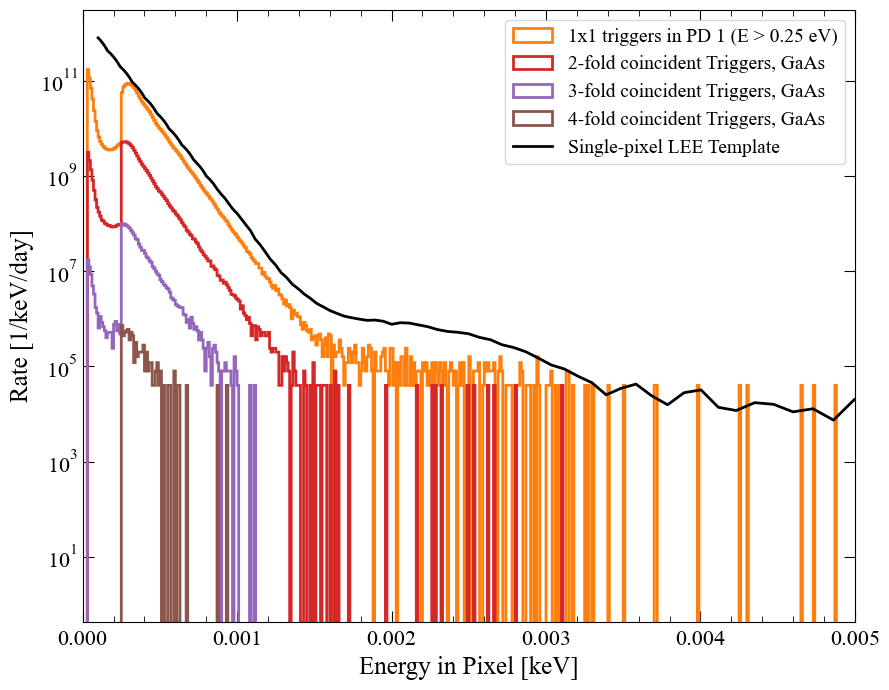

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
keV_bins = np.arange(0.03, 10, 0.01) * 1e-3

####################
# 1-fold coincidence
####################

single_pixel = n_above_th == 1
duration_days = eff_exposure_PD1_hours / 24
ax.hist(E1_full[single_pixel]*1e-3, bins=keV_bins,
        weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C1', lw=2,
        label=f'1x1 triggers in PD 1 (E > {E_th:.2f} eV)')
hist_E_E1_single, bin_edges = np.histogram(E1_full[single_pixel]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(single_pixel), 1/np.diff(keV_bins)[0]/duration_days))
R_single_PD_A = sum(hist_E_E1_single * np.diff(bin_edges))
print(f'Effective 1-fold exposure in PD 1: {duration_days:.2f} days')

# # ####################
# # # 2-fold coincidence
# # ####################

detected = n_above_th == 2
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C3', lw=2,
        label='2-fold coincident Triggers, GaAs')

hist_E_2fold, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_2fold = sum(hist_E_2fold * np.diff(bin_edges))


# # ####################
# # # 3-fold coincidence
# # ####################

detected = n_above_th == 3
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C4', lw=2,
        label='3-fold coincident Triggers, GaAs')

hist_E_3fold, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_3fold = sum(hist_E_3fold * np.diff(bin_edges))



# # ####################
# # # 4-fold coincidence
# # ####################

detected = n_above_th == 4
ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
        weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
        histtype='step', color='C5', lw=2,
        label='4-fold coincident Triggers, GaAs')

hist_E_4fold, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
                                 weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
R_coincident_4fold = sum(hist_E_4fold * np.diff(bin_edges))

# # ####################
# # # Adding delta delta cut
# # ####################

# detected = (E0_full > E_th_GaAs) * (E1_full > E_th_PD) * (E2_full > E_th_PD) * (delta_delta_full < 9)
# detected_overall = np.copy(detected)
# ax.hist(E0_full[detected]*1e-3, bins=keV_bins,
#         weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
#         histtype='step', color='C6', lw=2, linestyle=':',
#         label='3-fold + Delta Chi2 < 9, GaAs')
# ax.hist(E1_full[detected]*1e-3, bins=keV_bins,
#         weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days),
#         histtype='step', color='C7', lw=2, linestyle=':',
#         label='3-fold + Delta Chi2 < 9, PD 1')

# hist_E_3fold_delta_PD, bin_edges = np.histogram(E1_full[detected]*1e-3, bins=keV_bins,
#                                  weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
# hist_E_3fold_delta_GaAs, bin_edges = np.histogram(E0_full[detected]*1e-3, bins=keV_bins,
#                                  weights=np.full(sum(detected), 1/np.diff(keV_bins)[0]/duration_days))
# R_coincident_3fold_delta = sum(hist_E_3fold_delta_GaAs * np.diff(bin_edges))

# # Export to a file
# E_save = 0.5 * (keV_bins[1:] + keV_bins[:-1])
# np.savetxt(dirname + 'background_spectrum_3fold.txt',
#            np.column_stack((E_save, hist_E_3fold_delta_GaAs)),
#            header='Energy [keV]     dRdE GaAs [1/keV/day]',
#            fmt='%.4e')

# # ####################
# # # Wrapping up
# # ####################


#E_arr, dRdE_arr, _ = runnp.loadtxt('Run57_LEE_templates/combined_spectra_shared57_CRESST_extrap.txt', unpack=True)
E_arr = np.geomspace(0.1e-3, 100e-3, 250)
dRdE_arr = run57_lee_bkgd()(E_arr) * 86400
ax.plot(E_arr, dRdE_arr, color='k', label='Single-pixel LEE Template', lw=2)

ax.set_yscale('log')
ax.set_xlabel('Energy in Pixel [keV]')
ax.set_ylabel('Rate [1/keV/day]')
#ax.set_ylim([1e2, 1e10])
ax.set_xlim([0, 5e-3])

ax.legend(loc='best', fontsize=14)
fig.tight_layout()
fig.show()

print(f'\nRates [1/day]:')
print(f'1-fold in GaAs: {R_single_GaAs:.0f}')
print(f'1-fold in PD 1: {R_single_PD_A:.0f}')
print(f'2-fold in either PD: {R_coincident_2fold:.2e}')
print(f'3-fold in GaAs: {R_coincident_3fold:.2e}')
print(f'3-fold in GaAs with Delta Chi2 < 9: {R_coincident_3fold_delta:.2e}')

print('\nRaw Numbers:')
print(f'Number of detected events: {len(E0_full):,}')
print(f'Number of events passing the 2-fold cut: {sum(detected_2fold):,}')
print(f'Number of events passing all cuts: {sum(detected_overall):,}')



In [20]:
(50/25.8)**4 * 6 / 24 * 47

165.74447490310484